In [3]:
! pip install kaggle wandb onnx -Ux
from google.colab import drive
drive.mount('/content/drive')


Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

no such option: -x
Mounted at /content/drive


In [4]:
! mkdir ~/.kaggle

In [6]:
!cp /content/drive/MyDrive/MLassignment4/MLassignment4/kaggle.json ~/.kaggle/kaggle.json

In [5]:
! chmod 600 ~/.kaggle/kaggle.json

chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [7]:
! kaggle competitions download challenges-in-representation-learning-facial-expression-recognition-challenge

100% 285M/285M [00:16<00:00, 18.2MB/s]



In [8]:
!unzip -q -o challenges-in-representation-learning-facial-expression-recognition-challenge.zip -d data

In [9]:
import wandb

wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 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


wandb: WARNING Invalid choice


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: smama23 (smama23-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [10]:
import torch                                            # Main PyTorch library
from torch import nn                                    # Layers and loss functions
from torch.optim import Adam                            # Adam optimizer
import torchvision.transforms as transforms            # Image preprocessing
from torch.utils.data import Dataset, DataLoader        # Dataset / batching
import matplotlib.pyplot as plt                         # Visualisation
from PIL import Image                                   # Build images from pixel arrays
import pandas as pd                                     # Tabular data (the csv)
import numpy as np                                      # Numerical operations
from sklearn.metrics import classification_report, confusion_matrix

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device available:", device)

Device available: cuda


In [11]:
PROJECT = "fer2013-emotion-recognition"

EMOTIONS = ["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]

CONFIG = {
    "arch": "SimpleCNN",
    "epochs": 30,
    "batch_size": 64,
    "lr": 1e-3,
    "optimizer": "Adam",
    "weight_decay": 0.0,
    "dropout": 0.0,
    "augment": False,
    "num_classes": 7,
}
CONFIG

{'arch': 'SimpleCNN',
 'epochs': 30,
 'batch_size': 64,
 'lr': 0.001,
 'optimizer': 'Adam',
 'weight_decay': 0.0,
 'dropout': 0.0,
 'augment': False,
 'num_classes': 7}

In [12]:
df = pd.read_csv("data/icml_face_data.csv")
df.columns = df.columns.str.strip()
print(df['Usage'].value_counts())
df.head()

Usage
Training       28709
PublicTest      3589
PrivateTest     3589
Name: count, dtype: int64


,emotion,Usage,pixels
0,0,Training,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1,0,Training,151 150 147 155 148 133 111 140 170 174 182 15...
2,2,Training,231 212 156 164 174 138 161 173 182 200 106 38...
3,4,Training,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...
4,6,Training,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...


In [13]:
def parse_pixels(series):
    """Turn the space-separated pixel strings into an (N, 48, 48) uint8 array."""
    return np.stack([
        np.array(p.split(), dtype=np.uint8).reshape(48, 48) for p in series
    ])

def split_xy(frame):
    return parse_pixels(frame['pixels']), frame['emotion'].to_numpy(dtype=np.int64)

X_train, y_train = split_xy(df[df['Usage'] == 'Training'])
X_val,   y_val   = split_xy(df[df['Usage'] == 'PublicTest'])
X_test,  y_test  = split_xy(df[df['Usage'] == 'PrivateTest'])

print("train:", X_train.shape, "| val:", X_val.shape, "| test:", X_test.shape)

train: (28709, 48, 48) | val: (3589, 48, 48) | test: (3589, 48, 48)


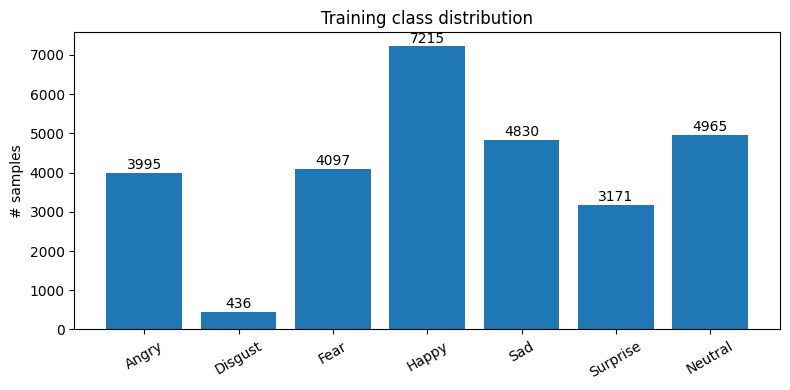

{'Angry': 3995, 'Disgust': 436, 'Fear': 4097, 'Happy': 7215, 'Sad': 4830, 'Surprise': 3171, 'Neutral': 4965}


In [14]:
counts = np.bincount(y_train, minlength=7)
plt.figure(figsize=(8, 4))
plt.bar(EMOTIONS, counts)
plt.title("Training class distribution")
plt.ylabel("# samples")
plt.xticks(rotation=30)
for i, c in enumerate(counts):
    plt.text(i, c + 100, str(c), ha='center')
plt.tight_layout(); plt.show()
print({EMOTIONS[i]: int(c) for i, c in enumerate(counts)})

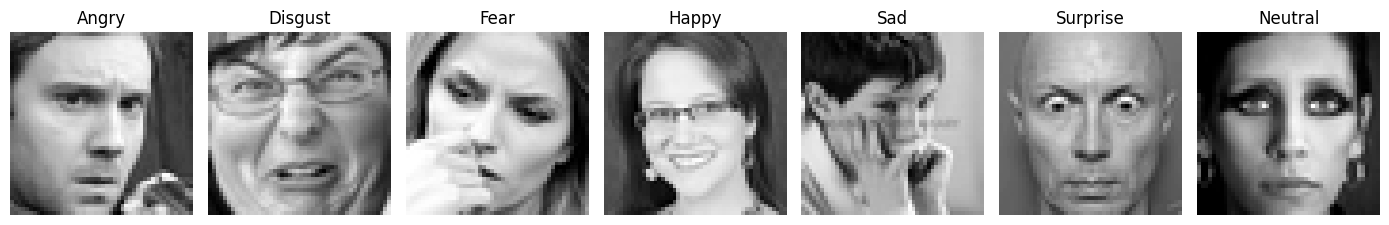

In [15]:
fig, axes = plt.subplots(1, 7, figsize=(14, 2.5))
for cls, ax in enumerate(axes):
    idx = np.where(y_train == cls)[0][0]
    ax.imshow(X_train[idx], cmap='gray')
    ax.set_title(EMOTIONS[cls]); ax.axis('off')
plt.tight_layout(); plt.show()

In [16]:
class FERDataset(Dataset):
    """Wraps the (N,48,48) uint8 images + integer labels with a torchvision transform."""
    def __init__(self, images, labels, transform):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, i):
        img = Image.fromarray(self.images[i])
        return self.transform(img), int(self.labels[i])


def build_transforms(augment):
    base = [transforms.ToTensor(), transforms.Normalize([0.5], [0.5])]
    if augment:
        return transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
        ] + base)
    return transforms.Compose(base)


def build_loaders(config):
    train_tf = build_transforms(config["augment"])
    eval_tf = build_transforms(False)
    train_ds = FERDataset(X_train, y_train, train_tf)
    val_ds   = FERDataset(X_val,   y_val,   eval_tf)
    test_ds  = FERDataset(X_test,  y_test,  eval_tf)
    bs = config["batch_size"]
    return (
        DataLoader(train_ds, batch_size=bs, shuffle=True,  num_workers=2, pin_memory=True),
        DataLoader(val_ds,   batch_size=bs, shuffle=False, num_workers=2, pin_memory=True),
        DataLoader(test_ds,  batch_size=bs, shuffle=False, num_workers=2, pin_memory=True),
    )

train_loader, val_loader, test_loader = build_loaders(CONFIG)
xb, yb = next(iter(train_loader))
print("batch images:", xb.shape, "| batch labels:", yb.shape, "| pixel range:", (xb.min().item(), xb.max().item()))

batch images: torch.Size([64, 1, 48, 48]) | batch labels: torch.Size([64]) | pixel range: (-1.0, 1.0)


In [17]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=7, dropout=0.0):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # 48x48
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                              # 24x24
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # 24x24
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                              # 12x12
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 12 * 12, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def build_model(config):
    return SimpleCNN(num_classes=config["num_classes"], dropout=config["dropout"])

# Parameter count
_m = build_model(CONFIG)
print(_m)
print("Trainable params:", sum(p.numel() for p in _m.parameters() if p.requires_grad))

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=9216, out_features=128, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.0, inplace=False)
    (4): Linear(in_features=128, out_features=7, bias=True)
  )
)
Trainable params: 1199495


In [18]:
model = build_model(CONFIG).to(device)
dummy = torch.randn(8, 1, 48, 48, device=device)
out = model(dummy)
print("forward output shape:", out.shape)
assert out.shape == (8, 7), "Output shape is wrong!"
print("Forward check passed.")

forward output shape: torch.Size([8, 7])
Forward check passed.


In [19]:
model = build_model(CONFIG).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=1e-3)

ob_x, ob_y = next(iter(train_loader))
ob_x, ob_y = ob_x[:32].to(device), ob_y[:32].to(device)

model.train()
for step in range(200):
    optimizer.zero_grad()
    loss = criterion(model(ob_x), ob_y)
    loss.backward()
    optimizer.step()
    if step % 40 == 0 or step == 199:
        acc = (model(ob_x).argmax(1) == ob_y).float().mean().item()
        print(f"step {step:3d} | loss {loss.item():.4f} | batch acc {acc:.2f}")
print("Backward check passed if loss -> ~0 and acc -> 1.0")

step   0 | loss 1.9481 | batch acc 0.31
step  40 | loss 0.0000 | batch acc 1.00
step  80 | loss 0.0000 | batch acc 1.00
step 120 | loss 0.0000 | batch acc 1.00
step 160 | loss 0.0000 | batch acc 1.00
step 199 | loss 0.0000 | batch acc 1.00
Backward check passed if loss -> ~0 and acc -> 1.0


In [20]:
def run_epoch(model, loader, criterion, optimizer=None):
    """One pass over `loader`. If optimizer is None -> evaluation (no grad)."""
    train = optimizer is not None
    model.train() if train else model.eval()
    total_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            if train:
                optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * x.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            n += x.size(0)
    return total_loss / n, correct / n


@torch.no_grad()
def collect_preds(model, loader):
    model.eval()
    preds, targets = [], []
    for x, y in loader:
        preds.append(model(x.to(device)).argmax(1).cpu())
        targets.append(y)
    return torch.cat(preds).numpy(), torch.cat(targets).numpy()

In [25]:
def run_experiment(config, run_name):
    """Train one configuration end-to-end and log everything to W&B."""
    train_loader, val_loader, test_loader = build_loaders(config)
    run = wandb.init(project=PROJECT, name=run_name, group=config["arch"],
                     config=config, reinit=True)

    model = build_model(config).to(device)
    wandb.watch(model, log="all", log_freq=200)
    criterion = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=config["lr"],
                     weight_decay=config["weight_decay"])

    history = {"train_acc": [], "val_acc": [], "train_loss": [], "val_loss": []}
    best_val = 0.0
    for epoch in range(config["epochs"]):
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer)
        va_loss, va_acc = run_epoch(model, val_loader, criterion)
        best_val = max(best_val, va_acc)
        wandb.log({"epoch": epoch, "train_loss": tr_loss, "train_acc": tr_acc,
                   "val_loss": va_loss, "val_acc": va_acc})
        for k, v in zip(history, [tr_acc, va_acc, tr_loss, va_loss]):
            history[k].append(v)
        print(f"epoch {epoch+1:2d}/{config['epochs']} | "
              f"train_loss {tr_loss:.3f} acc {tr_acc:.3f} | "
              f"val_loss {va_loss:.3f} acc {va_acc:.3f}")

    te_loss, te_acc = run_epoch(model, test_loader, criterion)
    preds, targets = collect_preds(model, test_loader)
    print(f"\nPrivateTest accuracy: {te_acc:.4f}")
    print(classification_report(targets, preds, target_names=EMOTIONS, digits=3))

    wandb.summary["test_acc"] = te_acc
    wandb.summary["test_loss"] = te_loss
    wandb.summary["best_val_acc"] = best_val
    wandb.summary["overfit_gap"] = history["train_acc"][-1] - history["val_acc"][-1]
    wandb.log({"confusion_matrix": wandb.plot.confusion_matrix(
        y_true=targets, preds=preds, class_names=EMOTIONS)})

    try:
        onnx_path = f"{run_name}.onnx"
        torch.onnx.export(model, torch.randn(1, 1, 48, 48, device=device), onnx_path,
                          input_names=["input"], output_names=["logits"],
                          dynamic_axes={"input": {0: "batch"}, "logits": {0: "batch"}},
                          dynamo=False)
        model_file = onnx_path
    except Exception as e:
        print(f"ONNX export failed ({e}); falling back to .pth state_dict.")
        model_file = f"{run_name}.pth"
        torch.save(model.state_dict(), model_file)

    art = wandb.Artifact(run_name, type="model", metadata={"test_acc": te_acc})
    art.add_file(model_file)
    run.log_artifact(art)

    run.finish()
    return model, history, te_acc

In [26]:
model, history, test_acc = run_experiment(CONFIG, run_name="SimpleCNN-baseline-lr0.001-bs64")

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train_acc,▁▂▃▃▄▅▅▆▇▇▇███████████████████
train_loss,█▇▆▆▅▄▄▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▄▆▇█▆▇█▇▇█▇▇▇▆▇█▇▇▆▇█▆▆▇▆▇▇▇▆
val_loss,▁▁▁▁▁▁▂▂▂▃▃▄▅▅▆▆▆▆▇▆▇▇▇▇▇▇████
best_val_acc,0.54918
epoch,29
overfit_gap,0.47175
test_acc,0.52549
test_loss,4.21444
train_acc,0.98972


epoch  1/30 | train_loss 1.565 acc 0.385 | val_loss 1.396 acc 0.468
epoch  2/30 | train_loss 1.326 acc 0.494 | val_loss 1.300 acc 0.496
epoch  3/30 | train_loss 1.202 acc 0.543 | val_loss 1.264 acc 0.522
epoch  4/30 | train_loss 1.085 acc 0.594 | val_loss 1.224 acc 0.531
epoch  5/30 | train_loss 0.967 acc 0.644 | val_loss 1.254 acc 0.539
epoch  6/30 | train_loss 0.834 acc 0.695 | val_loss 1.304 acc 0.534
epoch  7/30 | train_loss 0.698 acc 0.747 | val_loss 1.414 acc 0.529
epoch  8/30 | train_loss 0.572 acc 0.797 | val_loss 1.546 acc 0.542
epoch  9/30 | train_loss 0.445 acc 0.847 | val_loss 1.728 acc 0.522
epoch 10/30 | train_loss 0.335 acc 0.887 | val_loss 1.996 acc 0.521
epoch 11/30 | train_loss 0.250 acc 0.919 | val_loss 2.257 acc 0.511
epoch 12/30 | train_loss 0.186 acc 0.942 | val_loss 2.474 acc 0.524
epoch 13/30 | train_loss 0.135 acc 0.961 | val_loss 2.771 acc 0.520
epoch 14/30 | train_loss 0.105 acc 0.971 | val_loss 2.970 acc 0.520
epoch 15/30 | train_loss 0.096 acc 0.973 | val_l

/tmp/ipykernel_3484/2352557833.py:41: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(model, torch.randn(1, 1, 48, 48, device=device), onnx_path,


ONNX export failed (Module onnx is not installed!); falling back to .pth state_dict.


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train_acc,▁▂▃▃▄▅▅▆▆▇▇▇██████████████████
train_loss,█▇▆▆▅▅▄▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▄▆▇█▇▇█▆▆▅▆▆▆▇▆▆▆▆▅▅▅▇▆▆▅▅▆▅▅
val_loss,▁▁▁▁▁▁▁▂▂▂▃▃▄▄▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇█
best_val_acc,0.54166
epoch,29
overfit_gap,0.47673
test_acc,0.5294
test_loss,4.76804
train_acc,0.98523


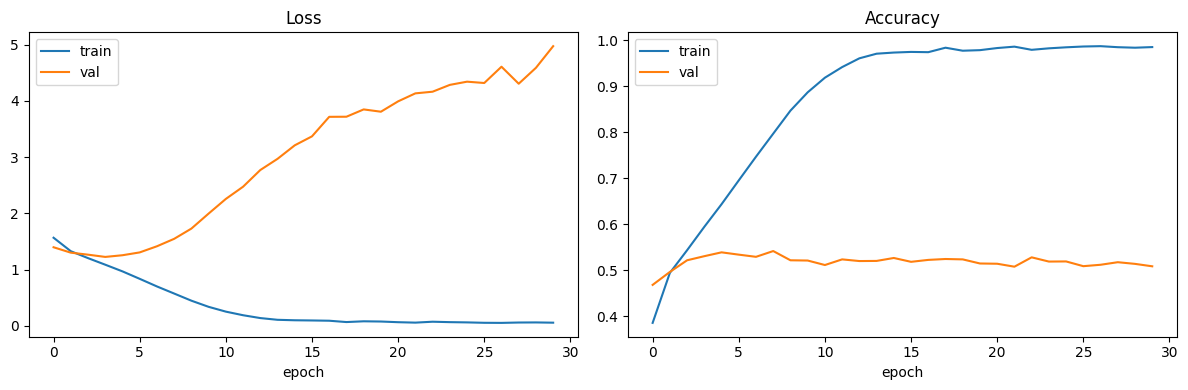

final train acc 0.985 | final val acc 0.508 | gap 0.477


In [27]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history["train_loss"], label="train"); ax[0].plot(history["val_loss"], label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(history["train_acc"], label="train"); ax[1].plot(history["val_acc"], label="val")
ax[1].set_title("Accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.show()
print(f"final train acc {history['train_acc'][-1]:.3f} | "
      f"final val acc {history['val_acc'][-1]:.3f} | "
      f"gap {history['train_acc'][-1] - history['val_acc'][-1]:.3f}")

In [28]:
sweep_results = {}

for lr in [1e-2, 1e-3, 1e-4]:
    cfg = {**CONFIG, "lr": lr, "epochs": 15}
    name = f"SimpleCNN-lr{lr}-bs{cfg['batch_size']}"
    _, _, acc = run_experiment(cfg, run_name=name)
    sweep_results[name] = acc

epoch  1/15 | train_loss 1.723 acc 0.334 | val_loss 1.553 acc 0.401
epoch  2/15 | train_loss 1.556 acc 0.395 | val_loss 1.523 acc 0.391
epoch  3/15 | train_loss 1.521 acc 0.409 | val_loss 1.543 acc 0.396
epoch  4/15 | train_loss 1.498 acc 0.417 | val_loss 1.504 acc 0.410
epoch  5/15 | train_loss 1.471 acc 0.427 | val_loss 1.509 acc 0.404
epoch  6/15 | train_loss 1.454 acc 0.436 | val_loss 1.496 acc 0.421
epoch  7/15 | train_loss 1.439 acc 0.442 | val_loss 1.494 acc 0.419
epoch  8/15 | train_loss 1.428 acc 0.448 | val_loss 1.508 acc 0.430
epoch  9/15 | train_loss 1.423 acc 0.449 | val_loss 1.498 acc 0.423
epoch 10/15 | train_loss 1.417 acc 0.451 | val_loss 1.523 acc 0.422
epoch 11/15 | train_loss 1.404 acc 0.455 | val_loss 1.496 acc 0.425
epoch 12/15 | train_loss 1.384 acc 0.465 | val_loss 1.504 acc 0.433
epoch 13/15 | train_loss 1.380 acc 0.469 | val_loss 1.493 acc 0.421
epoch 14/15 | train_loss 1.370 acc 0.471 | val_loss 1.524 acc 0.420
epoch 15/15 | train_loss 1.349 acc 0.482 | val_l

/tmp/ipykernel_3484/2352557833.py:41: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(model, torch.randn(1, 1, 48, 48, device=device), onnx_path,


ONNX export failed (Module onnx is not installed!); falling back to .pth state_dict.


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_acc,▁▄▅▅▅▆▆▆▆▇▇▇▇▇█
train_loss,█▅▄▄▃▃▃▂▂▂▂▂▂▁▁
val_acc,▃▁▂▄▃▆▆▇▆▆▇█▆▆▅
val_loss,█▅▇▂▃▁▁▃▂▅▁▂▁▅▅
best_val_acc,0.43299
epoch,14
overfit_gap,0.06765
test_acc,0.43076
test_loss,1.48396
train_acc,0.4817


epoch  1/15 | train_loss 1.591 acc 0.374 | val_loss 1.447 acc 0.451
epoch  2/15 | train_loss 1.365 acc 0.479 | val_loss 1.335 acc 0.490
epoch  3/15 | train_loss 1.242 acc 0.531 | val_loss 1.303 acc 0.498
epoch  4/15 | train_loss 1.131 acc 0.574 | val_loss 1.256 acc 0.522
epoch  5/15 | train_loss 1.025 acc 0.618 | val_loss 1.274 acc 0.533
epoch  6/15 | train_loss 0.919 acc 0.660 | val_loss 1.318 acc 0.535
epoch  7/15 | train_loss 0.815 acc 0.702 | val_loss 1.339 acc 0.538
epoch  8/15 | train_loss 0.710 acc 0.742 | val_loss 1.452 acc 0.522
epoch  9/15 | train_loss 0.605 acc 0.781 | val_loss 1.564 acc 0.530
epoch 10/15 | train_loss 0.505 acc 0.822 | val_loss 1.738 acc 0.529
epoch 11/15 | train_loss 0.406 acc 0.859 | val_loss 1.852 acc 0.527
epoch 12/15 | train_loss 0.325 acc 0.890 | val_loss 2.172 acc 0.510
epoch 13/15 | train_loss 0.258 acc 0.913 | val_loss 2.413 acc 0.520
epoch 14/15 | train_loss 0.208 acc 0.933 | val_loss 2.646 acc 0.517
epoch 15/15 | train_loss 0.163 acc 0.949 | val_l

...

epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_acc,▁▂▃▃▄▄▅▅▆▆▇▇███
train_loss,█▇▆▆▅▅▄▄▃▃▂▂▁▁▁
val_acc,▁▄▅▇███▇▇▇▇▆▇▆▅
val_loss,▂▁▁▁▁▁▁▂▂▃▄▅▆▇█
best_val_acc,0.53803
epoch,14
overfit_gap,0.44347
test_acc,0.53859
test_loss,2.70781
train_acc,0.9489


epoch  1/15 | train_loss 1.688 acc 0.331 | val_loss 1.591 acc 0.391
epoch  2/15 | train_loss 1.562 acc 0.401 | val_loss 1.536 acc 0.410
epoch  3/15 | train_loss 1.500 acc 0.431 | val_loss 1.488 acc 0.434
epoch  4/15 | train_loss 1.449 acc 0.451 | val_loss 1.451 acc 0.439
epoch  5/15 | train_loss 1.408 acc 0.467 | val_loss 1.414 acc 0.465
epoch  6/15 | train_loss 1.368 acc 0.482 | val_loss 1.402 acc 0.464
epoch  7/15 | train_loss 1.338 acc 0.496 | val_loss 1.374 acc 0.477
epoch  8/15 | train_loss 1.310 acc 0.510 | val_loss 1.368 acc 0.475
epoch  9/15 | train_loss 1.286 acc 0.515 | val_loss 1.350 acc 0.486
epoch 10/15 | train_loss 1.262 acc 0.528 | val_loss 1.340 acc 0.491
epoch 11/15 | train_loss 1.238 acc 0.538 | val_loss 1.343 acc 0.491
epoch 12/15 | train_loss 1.215 acc 0.547 | val_loss 1.327 acc 0.493
epoch 13/15 | train_loss 1.194 acc 0.552 | val_loss 1.334 acc 0.491
epoch 14/15 | train_loss 1.173 acc 0.565 | val_loss 1.332 acc 0.498
epoch 15/15 | train_loss 1.153 acc 0.575 | val_l

/tmp/ipykernel_3484/2352557833.py:41: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(model, torch.randn(1, 1, 48, 48, device=device), onnx_path,


ONNX export failed (Module onnx is not installed!); falling back to .pth state_dict.


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_acc,▁▃▄▄▅▅▆▆▆▇▇▇▇██
train_loss,█▆▆▅▄▄▃▃▃▂▂▂▂▁▁
val_acc,▁▂▄▄▆▆▆▆▇▇▇▇▇██
val_loss,█▇▅▄▃▃▂▂▂▂▂▁▁▁▁
best_val_acc,0.50181
epoch,14
overfit_gap,0.07292
test_acc,0.50042
test_loss,1.29572
train_acc,0.57473


In [29]:
cfg_reg = {**CONFIG, "epochs": 15, "dropout": 0.5, "weight_decay": 1e-4}
_, hist_reg, acc_reg = run_experiment(cfg_reg, run_name="SimpleCNN-reg-dropout0.5-wd1e-4")
sweep_results["SimpleCNN-reg-dropout0.5-wd1e-4"] = acc_reg
sweep_results

epoch  1/15 | train_loss 1.639 acc 0.353 | val_loss 1.467 acc 0.443
epoch  2/15 | train_loss 1.449 acc 0.443 | val_loss 1.348 acc 0.488
epoch  3/15 | train_loss 1.348 acc 0.483 | val_loss 1.315 acc 0.497
epoch  4/15 | train_loss 1.271 acc 0.518 | val_loss 1.249 acc 0.517
epoch  5/15 | train_loss 1.211 acc 0.540 | val_loss 1.260 acc 0.512
epoch  6/15 | train_loss 1.150 acc 0.560 | val_loss 1.224 acc 0.532
epoch  7/15 | train_loss 1.091 acc 0.586 | val_loss 1.226 acc 0.532
epoch  8/15 | train_loss 1.037 acc 0.606 | val_loss 1.227 acc 0.534
epoch  9/15 | train_loss 0.986 acc 0.627 | val_loss 1.232 acc 0.546
epoch 10/15 | train_loss 0.933 acc 0.643 | val_loss 1.240 acc 0.554
epoch 11/15 | train_loss 0.887 acc 0.661 | val_loss 1.247 acc 0.553
epoch 12/15 | train_loss 0.841 acc 0.677 | val_loss 1.270 acc 0.547
epoch 13/15 | train_loss 0.793 acc 0.695 | val_loss 1.342 acc 0.543
epoch 14/15 | train_loss 0.759 acc 0.707 | val_loss 1.353 acc 0.547
epoch 15/15 | train_loss 0.720 acc 0.725 | val_l

/tmp/ipykernel_3484/2352557833.py:41: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(model, torch.randn(1, 1, 48, 48, device=device), onnx_path,


ONNX export failed (Module onnx is not installed!); falling back to .pth state_dict.


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_acc,▁▃▃▄▅▅▅▆▆▆▇▇▇██
train_loss,█▇▆▅▅▄▄▃▃▃▂▂▂▁▁
val_acc,▁▄▄▅▅▆▆▇▇██▇▇▇█
val_loss,█▅▄▂▂▁▁▁▁▁▂▂▄▅▆
best_val_acc,0.55837
epoch,14
overfit_gap,0.16617
test_acc,0.56812
test_loss,1.30613
train_acc,0.72455


{'SimpleCNN-lr0.01-bs64': 0.43076065756478127,
 'SimpleCNN-lr0.001-bs64': 0.5385901365282808,
 'SimpleCNN-lr0.0001-bs64': 0.5004179437169128,
 'SimpleCNN-reg-dropout0.5-wd1e-4': 0.5681248258567846}

In [30]:
test_df = pd.read_csv("data/test.csv")
X_kaggle = parse_pixels(test_df['pixels'])
kaggle_ds = FERDataset(X_kaggle, np.zeros(len(X_kaggle), dtype=np.int64), build_transforms(False))
kaggle_loader = DataLoader(kaggle_ds, batch_size=128, shuffle=False)
kaggle_preds, _ = collect_preds(model, kaggle_loader)
pd.Series(kaggle_preds).to_csv("submission.csv", index=False, header=False)
print("Wrote submission.csv with", len(kaggle_preds), "predictions")

Wrote submission.csv with 7178 predictions
